# Baseline Accuracy

**RQ1 convergence.** Does the co-simulated loop converge to the monolithic
reference under macro-step refinement, and at what observed order?

No switching here. One FMI plant, one FMI controller, one FMI drive, against the
same model solved monolithically in OpenModelica. This is the floor: whatever
error the switching notebooks show has to be read against it.

In [17]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)

plt = set_professional_style(latex=True)
print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


In [18]:
# Pin the OpenModelica toolchain. OMPython resolves omc through OPENMODELICAHOME
# and PATH, so a second installation silently changes which compiler builds the
# reference - and therefore the trajectory every error below is measured against.
# The paper's comparison environment is pinned to 1.26.3
# (SysSimX-Framework-Paper/environments/README.md).
import os

OM_VERSION_EXPECTED = "1.26.3"
OM_HOME = Path(os.environ.get("SYSSIMX_OM_HOME", r"C:\Program Files\OpenModelica1.26.3-64bit"))
if next((c for c in (OM_HOME / "bin/omc.exe", OM_HOME / "bin/omc") if c.is_file()), None) is None:
    raise FileNotFoundError(f"No OpenModelica compiler under {OM_HOME}. Set SYSSIMX_OM_HOME.")
os.environ["OPENMODELICAHOME"] = str(OM_HOME)

from OMPython import OMCSessionZMQ

om_version = OMCSessionZMQ().sendExpression("getVersion()")
print(f"OpenModelica : {om_version}")
if OM_VERSION_EXPECTED not in om_version:
    raise RuntimeError(
        f"Expected OpenModelica {OM_VERSION_EXPECTED}, got {om_version}. The reference is only "
        f"comparable within one toolchain: set SYSSIMX_OM_HOME and OM_VERSION_EXPECTED together."
    )

OpenModelica : OpenModelica v1.26.3 (64-bit)


## Configuration

In [19]:
import evidence as ev

T0, T_END = 0.0, 1.0
DT_VALUES = (0.02, 0.01, 0.005, 0.001)
MODEL = "ControlledPendulum.Examples.NoContact.Baseline"

FIGURE_ID = "V2_baseline"
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PACKAGE = REPO / "demos" / "ControlledPendulum" / "src" / "modelica" / "ControlledPendulum"
FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

## Monolithic reference

In [20]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(
    fileName=str(PACKAGE / "package.mo"), modelName=MODEL, omhome=str(OM_HOME)
)
reference.buildModel()
reference.simulate(simargs={"stopTime": str(T_END)})
ref = {name: reference.getSolutions(name).flatten() for name in ("time", "theta")}
print(f"reference samples: {ref['time'].size}")

reference samples: 502


## Co-simulation sweep

The loop is deliberately plainer than the switching notebooks': no sensor chain,
no event connections. Only the macro step varies.

In [21]:
from syssimx import Connection, FMUComponent, System


def run_co_simulation(dt):
    setpoint = FMUComponent(name="Setpoint", fmu_path=FMU_PATHS["Trajectories"]["SetPoint"],
                            group="Reference")
    pid = FMUComponent(name="PID", fmu_path=FMU_PATHS["Controllers"]["PIDController"],
                       group="Controller")
    drive = FMUComponent(name="Drive", fmu_path=FMU_PATHS["Actuators"]["DriveDynamic"],
                         group="Actuator")
    plant = FMUComponent(name="Pendulum", fmu_path=FMU_PATHS["Plants"]["Pendulum_cvode"],
                         group="Plant")

    system = System(name="Controlled Pendulum")
    for comp in (setpoint, pid, drive, plant):
        system.add_component(comp)
    for connection in (
        Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
        Connection("Pendulum", "theta", "PID", "theta_meas"),
        Connection("PID", "u", "Drive", "u_control"),
        Connection("Drive", "torque", "Pendulum", "tau"),
        Connection("Pendulum", "omega", "Drive", "omega"),
    ):
        system.add_connection(connection)

    system.initialize(t0=T0)
    system.run(t0=T0, tf=T_END, dt=dt)
    return system.get_history()["Pendulum"]


runs = {dt: run_co_simulation(dt) for dt in DT_VALUES}
print(f"{len(runs)} macro steps swept: {list(DT_VALUES)}")

4 macro steps swept: [0.02, 0.01, 0.005, 0.001]


## Error and observed order

The order is **fitted**, not asserted: a least-squares slope of `log E` against
`log dt`. An earlier revision computed the errors and showed them only inside a
figure panel, so the numbers could not be re-checked without re-running.

In [22]:
rows = []
for dt, (t_cs, data) in runs.items():
    t_cs = np.asarray(t_cs, dtype=float)
    theta = np.asarray(data["theta"], dtype=float)
    metrics = ev.trajectory_error_metrics(t_cs, theta, ref["time"], ref["theta"])
    rows.append({"dt": dt, **metrics})

df = pd.DataFrame(rows).sort_values("dt", ascending=False).reset_index(drop=True)

def observed_order(steps, errors):
    """Least-squares slope of log error against log step, with R squared.

    A fitted order without its fit quality and its step range is not quotable:
    the slope alone cannot distinguish a clean power law from a curve that is
    not yet in the asymptotic regime.
    """
    steps = np.asarray(steps, dtype=float)
    errors = np.asarray(errors, dtype=float)
    usable = np.isfinite(errors) & (errors > 0.0)
    x, y = np.log(steps[usable]), np.log(errors[usable])
    slope, intercept = np.polyfit(x, y, 1)
    residual = y - (slope * x + intercept)
    ss_res = float(np.sum(residual**2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return float(slope), (1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan"))


def local_orders(steps, errors):
    """Order between consecutive steps; exposes a non-power-law sequence."""
    steps = np.asarray(steps, dtype=float)
    errors = np.asarray(errors, dtype=float)
    return [
        float(np.log(errors[i] / errors[i + 1]) / np.log(steps[i] / steps[i + 1]))
        for i in range(len(steps) - 1)
    ]


display(df.style.format({"e_inf": "{:.3e}", "e_2": "{:.3e}", "e_mean": "{:.3e}",
                         "dt": "{:.4g}", "n_samples": "{:.0f}"}).hide(axis="index"))

steps = df["dt"].to_numpy()
fit = {m: observed_order(steps, df[m].to_numpy()) for m in ("e_inf", "e_2")}
order = {m: fit[m][0] for m in fit}
r_squared = {m: fit[m][1] for m in fit}
local = {m: local_orders(steps, df[m].to_numpy()) for m in fit}
FIT_RANGE = (float(steps.min()), float(steps.max()))

print(f"fit range       : dt = {FIT_RANGE[0]:.4g} .. {FIT_RANGE[1]:.4g} s "
      f"({len(steps)} points)")
for metric in ("e_inf", "e_2"):
    pairs = "  ".join(f"{p:.2f}" for p in local[metric])
    print(f"{metric:<6}  order {order[metric]:.2f}   R^2 {r_squared[metric]:.4f}   "
          f"local: {pairs}")

# The local orders are the honest check on the fit. A spread across them means
# the coarsest steps are not in the asymptotic regime, and the single fitted
# slope is then an average over two different behaviours rather than an order.
for metric in ("e_inf", "e_2"):
    spread = max(local[metric]) - min(local[metric])
    if spread > 0.5:
        print(f"NOTE: {metric} local orders span {spread:.2f}. The coarsest steps are "
              f"probably not in the asymptotic regime; quote the range, not only the fit.")

dt,e_inf,e_2,e_mean,n_samples
0.02,2.499e-01,9.859e-02,7.361e-02,51
0.01,5.438e-02,1.337e-02,9.649e-03,101
0.005,2.302e-02,3.139e-03,1.404e-03,201
0.001,9.310e-04,1.055e-04,4.766e-05,1001


fit range       : dt = 0.001 .. 0.02 s (4 points)
e_inf   order 1.84   R^2 0.9946   local: 2.20  1.24  1.99
e_2     order 2.24   R^2 0.9951   local: 2.88  2.09  2.11
NOTE: e_inf local orders span 0.96. The coarsest steps are probably not in the asymptotic regime; quote the range, not only the fit.
NOTE: e_2 local orders span 0.79. The coarsest steps are probably not in the asymptotic regime; quote the range, not only the fit.


In [23]:
record(
    FIGURE_ID,
    {
        "dt": [float(v) for v in df["dt"]],
        "e_inf": [float(v) for v in df["e_inf"]],
        "e_2": [float(v) for v in df["e_2"]],
        "observed_order_e_inf": order["e_inf"],
        "observed_order_e_2": order["e_2"],
        "r_squared_e_inf": r_squared["e_inf"],
        "r_squared_e_2": r_squared["e_2"],
        "local_order_e_inf": local["e_inf"],
        "local_order_e_2": local["e_2"],
        "fit_dt_min": FIT_RANGE[0],
        "fit_dt_max": FIT_RANGE[1],
        "fit_n_points": int(len(df)),
        "t0": T0, "t_end": T_END, "model": MODEL,
        "openmodelica": om_version,
    },
    directory=RESULTS,
    notebook="02_baseline",
    smoke=False,
)

WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/V2_baseline.json')

## Figure

One panel: error against macro step, log-log, with the fitted slope. The
trajectory overlay that earlier revisions carried is dropped — it showed the same
loop the switching notebook already plots, and the convergence is the claim.

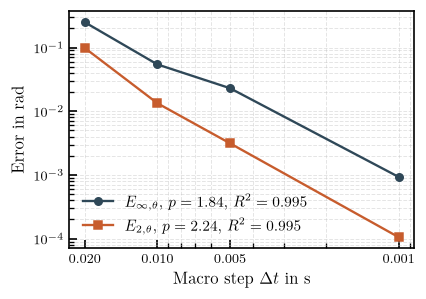

In [24]:
from matplotlib.ticker import ScalarFormatter
from plot_setup import METRIC_COLORS

dt_arr = df["dt"].to_numpy()

fig, ax = plt.subplots(figsize=(0.62 * FULL_WIDTH, 0.44 * FULL_WIDTH))

for metric, marker, label in (("e_inf", "o", r"$E_{\infty,\theta}$"),
                              ("e_2", "s", r"$E_{2,\theta}$")):
    ax.loglog(dt_arr, df[metric], color=METRIC_COLORS[metric], marker=marker,
              linewidth=1.4, markersize=4.5,
              label=rf"{label},  $p={order[metric]:.2f}$, $R^2={r_squared[metric]:.3f}$")

ax.invert_xaxis()
ax.set_xlabel(r"Macro step $\Delta t$ in $\mathrm{s}$")
ax.set_ylabel(r"Error in $\mathrm{rad}$")
ax.set_xticks(dt_arr)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc="lower left", frameon=False)

fig.tight_layout()
fig.savefig(OUT_DIR / f"{FIGURE_ID}.pdf", bbox_inches="tight")
plt.show()

## Reading the result

The fitted slope is the claimable quantity; quote it with the scenario and the
step range it was fitted over. The reference is the monolithic OpenModelica
solution of the same model, so this is *verification against a numerical
reference*, not validation — no experimental data enter here.